# Final Paper Project: Hotel Booking Cancellation Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
import shap

C:\Users\mahik\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and Clean the Data

The target variable is `is_canceled`.

To prevent data leakage, `reservation_status` and `reservation_status_date` are removed because they reveal the final booking outcome.


In [2]:
df = pd.read_csv("hotel_bookingsDATA.csv")

df_clean = df.copy()

# Fill missing values
df_clean["children"] = df_clean["children"].fillna(0)
df_clean["country"] = df_clean["country"].fillna("Unknown")
df_clean["agent"] = df_clean["agent"].fillna(0)
df_clean["company"] = df_clean["company"].fillna(0)

# Remove leakage columns
df_clean = df_clean.drop(["reservation_status", "reservation_status_date"], axis=1)

# Remove rows with no guests
df_clean = df_clean[df_clean["adults"] + df_clean["children"] + df_clean["babies"] > 0]

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Remaining missing values:", df_clean.isnull().sum().sum())

Original shape: (119390, 32)
Cleaned shape: (119210, 30)
Remaining missing values: 0


## 2. Feature Engineering

These engineered features provide clearer business meaning:
- `total_guests`
- `total_nights`
- `adr_per_guest`


In [3]:
df_clean["total_guests"] = (
    df_clean["adults"] + df_clean["children"] + df_clean["babies"]
)

df_clean["total_nights"] = (
    df_clean["stays_in_week_nights"] + df_clean["stays_in_weekend_nights"]
)

df_clean["adr_per_guest"] = df_clean["adr"] / df_clean["total_guests"]
df_clean["adr_per_guest"] = df_clean["adr_per_guest"].replace([np.inf, -np.inf], 0)
df_clean["adr_per_guest"] = df_clean["adr_per_guest"].fillna(0)

df_clean[["total_guests", "total_nights", "adr_per_guest"]].head()

,total_guests,total_nights,adr_per_guest
0,2.0,0,0.0
1,2.0,0,0.0
2,1.0,1,75.0
3,1.0,1,75.0
4,2.0,2,49.0


## 3. Key Exploratory Visualizations

These plots summarize the main patterns used in the final report.


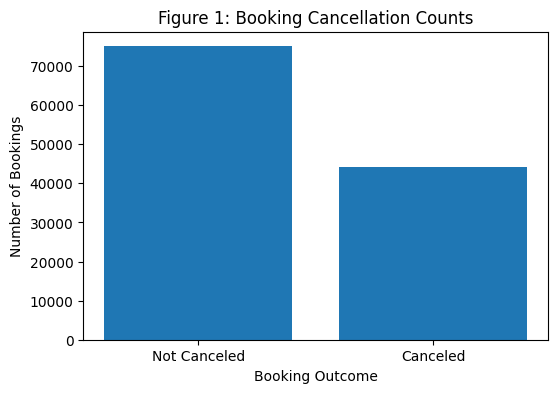

Cancellation rate: 0.3708


In [4]:
cancel_counts = df_clean["is_canceled"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Not Canceled", "Canceled"], cancel_counts.values)
plt.title("Figure 1: Booking Cancellation Counts")
plt.xlabel("Booking Outcome")
plt.ylabel("Number of Bookings")
plt.show()

print("Cancellation rate:", round(df_clean["is_canceled"].mean(), 4))

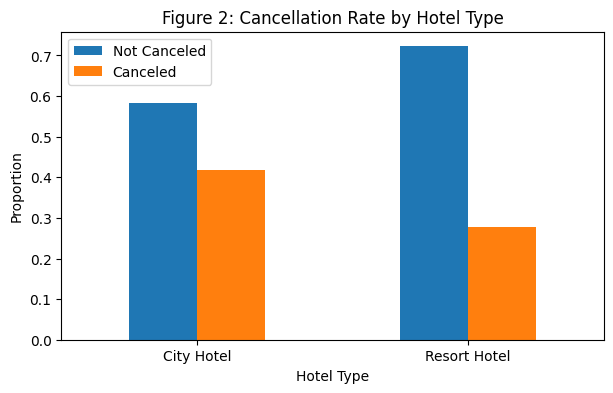

In [5]:
hotel_cancel = pd.crosstab(df_clean["hotel"], df_clean["is_canceled"], normalize="index")

hotel_cancel.plot(kind="bar", figsize=(7, 4))
plt.title("Figure 2: Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(["Not Canceled", "Canceled"])
plt.show()

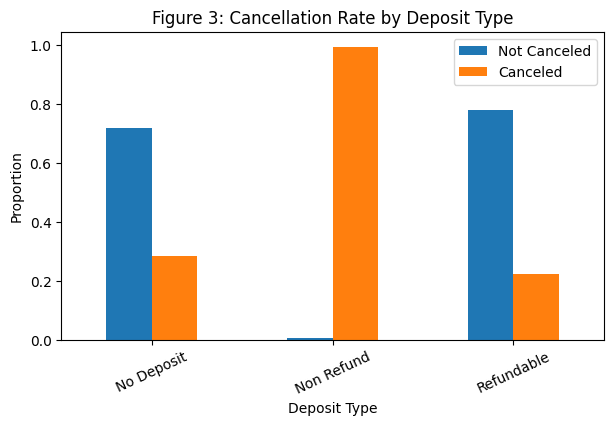

In [6]:
deposit_cancel = pd.crosstab(df_clean["deposit_type"], df_clean["is_canceled"], normalize="index")

deposit_cancel.plot(kind="bar", figsize=(7, 4))
plt.title("Figure 3: Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Proportion")
plt.xticks(rotation=25)
plt.legend(["Not Canceled", "Canceled"])
plt.show()

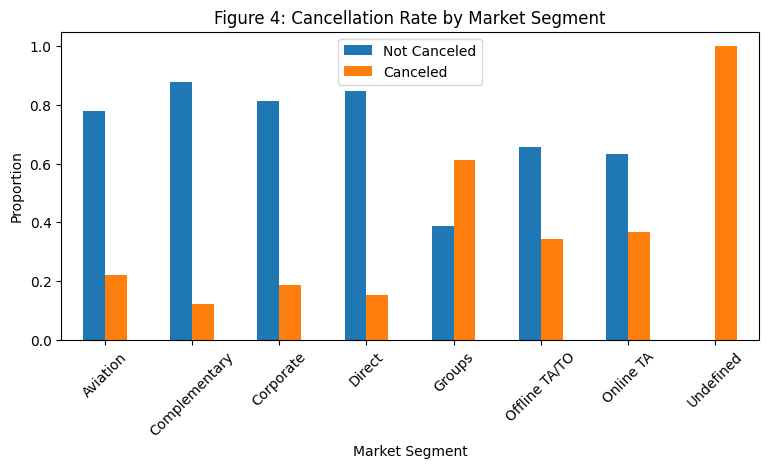

In [7]:
market_cancel = pd.crosstab(df_clean["market_segment"], df_clean["is_canceled"], normalize="index")

market_cancel.plot(kind="bar", figsize=(9, 4))
plt.title("Figure 4: Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(["Not Canceled", "Canceled"])
plt.show()

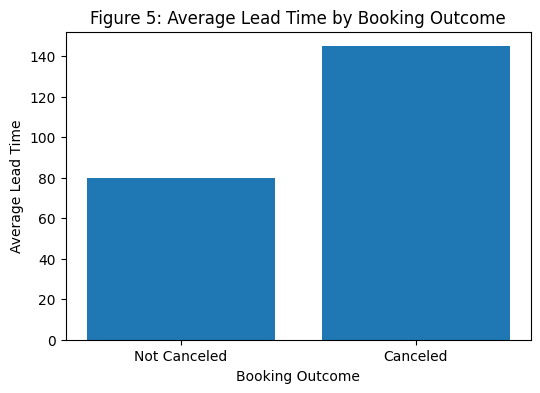

is_canceled
0     80.082028
1    144.886264
Name: lead_time, dtype: float64

In [8]:
lead_time_means = df_clean.groupby("is_canceled")["lead_time"].mean()

plt.figure(figsize=(6, 4))
plt.bar(["Not Canceled", "Canceled"], lead_time_means.values)
plt.title("Figure 5: Average Lead Time by Booking Outcome")
plt.xlabel("Booking Outcome")
plt.ylabel("Average Lead Time")
plt.show()

lead_time_means

## 4. Encode Features and Split Training/Testing Sets

The target column is separated before training. The split is stratified so the cancellation ratio is similar in training and testing data.


In [9]:
y = df_clean["is_canceled"]
X = df_clean.drop("is_canceled", axis=1)

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (95368, 249)
Testing shape: (23842, 249)


## 5. K-Means Segmentation and PCA Visualization

K-Means creates booking/customer segments. PCA is used only to visualize the clusters in two dimensions.


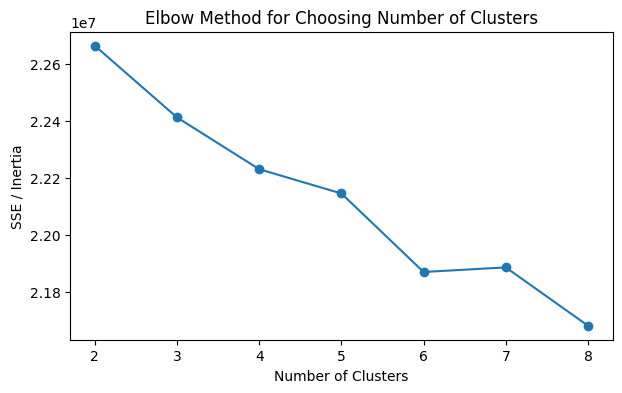

In [10]:
k_values = range(2, 9)
sse = []

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_train_scaled)
    sse.append(kmeans_temp.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), sse, marker="o")
plt.title("Elbow Method for Choosing Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("SSE / Inertia")
plt.show()


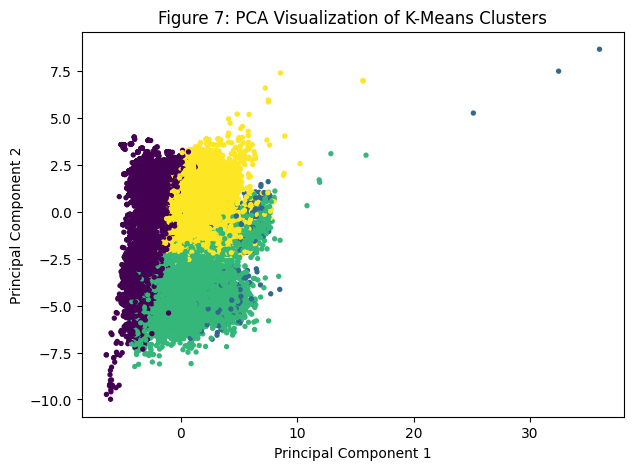

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

train_clusters = kmeans.fit_predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=train_clusters, s=8)
plt.title("Figure 7: PCA Visualization of K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

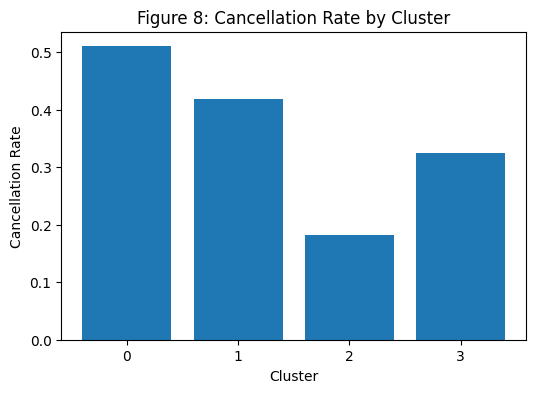

cluster
0    0.509830
1    0.418947
2    0.182296
3    0.324190
Name: is_canceled, dtype: float64

In [12]:
cluster_df = pd.DataFrame({
    "cluster": train_clusters,
    "is_canceled": y_train.values
})

cluster_cancel_rates = cluster_df.groupby("cluster")["is_canceled"].mean()

plt.figure(figsize=(6, 4))
plt.bar(cluster_cancel_rates.index.astype(str), cluster_cancel_rates.values)
plt.title("Figure 8: Cancellation Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Cancellation Rate")
plt.show()

cluster_cancel_rates

## 6. Train Prediction Models

The cluster label is added as an additional feature, creating a hybrid segmentation + prediction workflow.


In [13]:
X_train_model = X_train.copy()
X_test_model = X_test.copy()

X_train_model["cluster"] = train_clusters
X_test_model["cluster"] = test_clusters

model_scaler = StandardScaler()
X_train_model_scaled = model_scaler.fit_transform(X_train_model)
X_test_model_scaled = model_scaler.transform(X_test_model)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_model_scaled, y_train)

log_pred = log_model.predict(X_test_model_scaled)
log_prob = log_model.predict_proba(X_test_model_scaled)[:, 1]

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=12,
    class_weight="balanced"
)

rf_model.fit(X_train_model, y_train)

rf_pred = rf_model.predict(X_test_model)
rf_prob = rf_model.predict_proba(X_test_model)[:, 1]

## 7. Model Evaluation

Multiple metrics are used because accuracy alone may be misleading when cancellation classes are imbalanced.


In [14]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

results_df = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, log_pred, log_prob),
    evaluate_model("Random Forest", y_test, rf_pred, rf_prob)
])

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.816039,0.800946,0.670475,0.729926,0.895697
1,Random Forest,0.852739,0.812771,0.783258,0.797742,0.929866


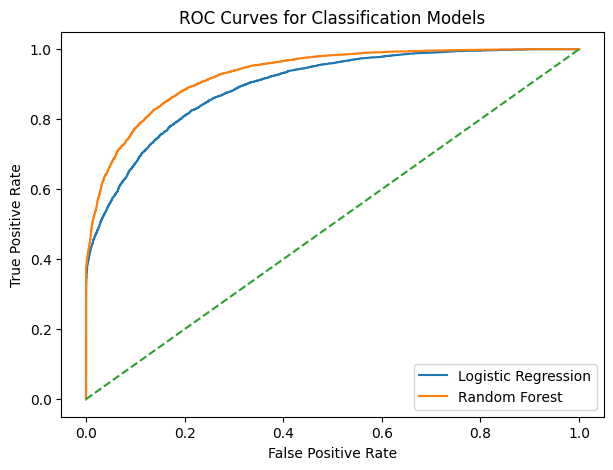

In [15]:
log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7, 5))
plt.plot(log_fpr, log_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curves for Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

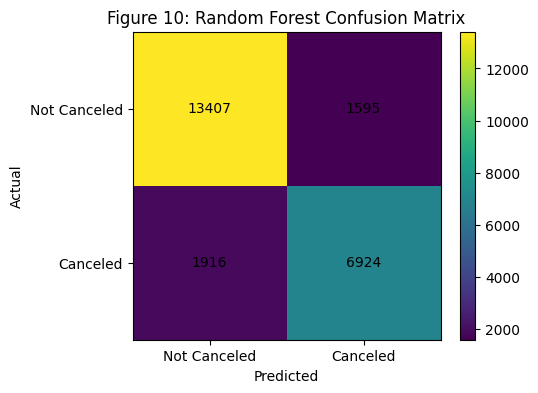

array([[13407,  1595],
       [ 1916,  6924]])

In [16]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5, 4))
plt.imshow(rf_cm)
plt.title("Figure 10: Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Not Canceled", "Canceled"])
plt.yticks([0, 1], ["Not Canceled", "Canceled"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, rf_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

rf_cm

## 8. Feature Importance

Random Forest feature importance identifies variables that most strongly contributed to prediction.


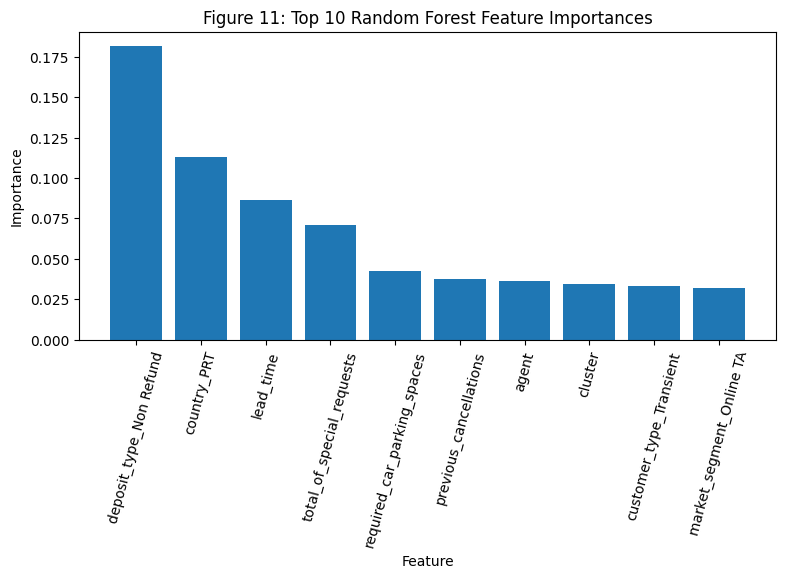

,Feature,Importance
244,deposit_type_Non Refund,0.181298
172,country_PRT,0.113081
0,lead_time,0.086202
18,total_of_special_requests,0.071141
17,required_car_parking_spaces,0.042345
10,previous_cancellations,0.037495
13,agent,0.036286
249,cluster,0.034489
247,customer_type_Transient,0.033243
220,market_segment_Online TA,0.031992


In [17]:
feature_importance = pd.DataFrame({
    "Feature": X_train_model.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(9, 4))
plt.bar(top_features["Feature"], top_features["Importance"])
plt.title("Figure 11: Top 10 Random Forest Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=75)
plt.show()

top_features

## 9. SHAP Explainability

This section runs only if SHAP is installed. SHAP provides a more detailed explanation of how features affect model predictions.


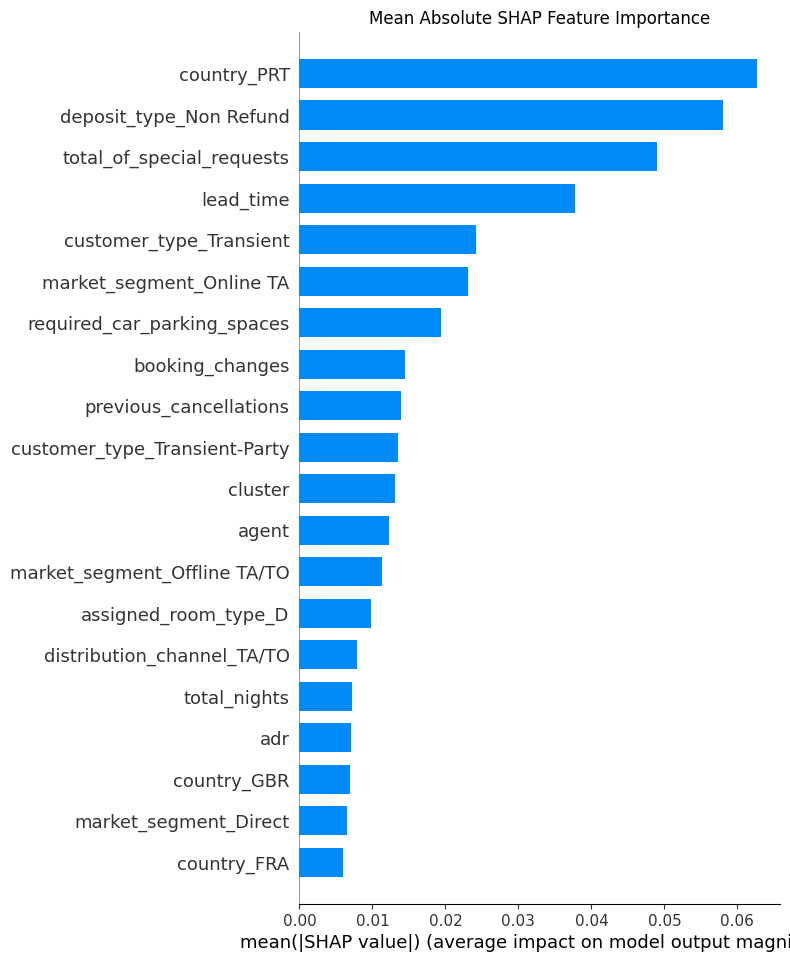

In [18]:
sample_size = min(1000, len(X_test_model))
X_shap = X_test_model.sample(sample_size, random_state=42)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_to_plot = shap_values[:, :, 1]
else:
    shap_values_to_plot = shap_values

# shap.summary_plot(shap_values_to_plot, X_shap, show=False)
# plt.title("Figure 12: SHAP Summary Plot for Random Forest Model")
# plt.show()

shap.summary_plot(shap_values_to_plot, X_shap, plot_type="bar", show=False)
plt.title("Mean Absolute SHAP Feature Importance")
plt.show()

## 10. Error Analysis

This section focuses on the mistakes made by the Random Forest model.


In [19]:
error_df = X_test_model.copy()
error_df["actual"] = y_test.values
error_df["predicted"] = rf_pred

false_positives = error_df[(error_df["predicted"] == 1) & (error_df["actual"] == 0)]
false_negatives = error_df[(error_df["predicted"] == 0) & (error_df["actual"] == 1)]

print("Number of false positives:", len(false_positives))
print("Number of false negatives:", len(false_negatives))

print("Average lead time (False Positives):", round(false_positives["lead_time"].mean(), 2))
print("Average lead time (False Negatives):", round(false_negatives["lead_time"].mean(), 2))

Number of false positives: 1595
Number of false negatives: 1916
Average lead time (False Positives): 106.13
Average lead time (False Negatives): 79.54


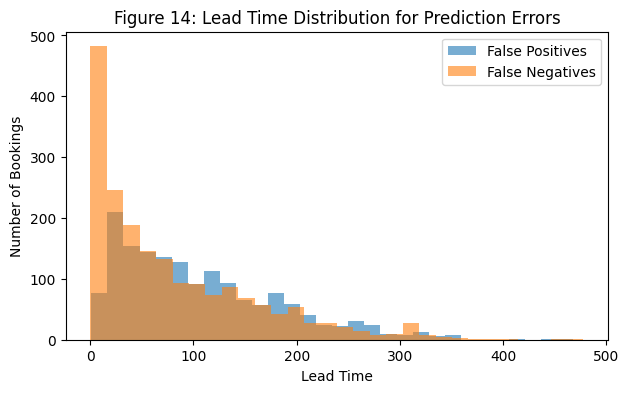

In [20]:
plt.figure(figsize=(7, 4))
plt.hist(false_positives["lead_time"], bins=30, alpha=0.6, label="False Positives")
plt.hist(false_negatives["lead_time"], bins=30, alpha=0.6, label="False Negatives")
plt.title("Figure 14: Lead Time Distribution for Prediction Errors")
plt.xlabel("Lead Time")
plt.ylabel("Number of Bookings")
plt.legend()
plt.show()

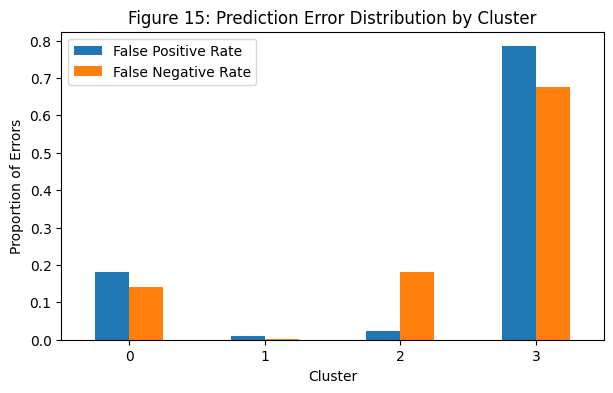

,False Positive Rate,False Negative Rate
cluster,,
0,0.180564,0.141962
1,0.011285,0.002610
2,0.023824,0.180063
3,0.784326,0.675365


In [21]:
fp_cluster = false_positives["cluster"].value_counts(normalize=True)
fn_cluster = false_negatives["cluster"].value_counts(normalize=True)

error_cluster_df = pd.DataFrame({
    "False Positive Rate": fp_cluster,
    "False Negative Rate": fn_cluster
}).fillna(0)

error_cluster_df.plot(kind="bar", figsize=(7, 4))
plt.title("Figure 15: Prediction Error Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Proportion of Errors")
plt.xticks(rotation=0)
plt.show()

error_cluster_df